In [ ]:
import pandas as pd
import numpy as np

# =========================
# 1. Load data
# =========================
df = pd.read_csv("global-data-on-sustainable-energy (1).csv")

# =========================
# 2. Standardize column names
# =========================
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
)

# =========================
# 3. Basic type cleaning
# =========================
if "year" in df.columns:
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

if "entity" in df.columns:
    df["entity"] = df["entity"].astype(str).str.strip()

# drop exact duplicate rows
df = df.drop_duplicates()

# optional: drop duplicate country-year records, keep first
if {"entity", "year"}.issubset(df.columns):
    df = df.drop_duplicates(subset=["entity", "year"])

# =========================
# 4. Sort panel data
# =========================
if {"entity", "year"}.issubset(df.columns):
    df = df.sort_values(["entity", "year"]).reset_index(drop=True)

# =========================
# 5. Restrict to proposal time window: 2000–2020
# =========================
if "year" in df.columns:
    df = df[(df["year"] >= 2000) & (df["year"] <= 2020)].copy()

# =========================
# 6. Clean numeric columns
# =========================
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# interpolate numeric columns within each country
if {"entity", "year"}.issubset(df.columns) and len(num_cols) > 0:
    df[num_cols] = df.groupby("entity")[num_cols].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    )

    # forward/backward fill any remaining missing numeric values within country
    df[num_cols] = df.groupby("entity")[num_cols].transform(
        lambda x: x.ffill().bfill()
    )

# =========================
# 7. Drop columns with too much missingness
# =========================
missing_ratio = df.isna().mean()
cols_to_keep = missing_ratio[missing_ratio < 0.40].index
df = df[cols_to_keep].copy()

# =========================
# 8. Light outlier treatment for numeric columns
#    (winsorize at 1st and 99th percentile)
# =========================
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in num_cols:
    if col != "year":
        q1 = df[col].quantile(0.01)
        q99 = df[col].quantile(0.99)
        df[col] = df[col].clip(lower=q1, upper=q99)

# =========================
# 9. Final checks
# =========================
print("Shape:", df.shape)
print("\nMissing values by column:")
print(df.isna().sum().sort_values(ascending=False).head(20))

print("\nData types:")
print(df.dtypes)

print("\nPreview:")
print(df.head())

# save cleaned dataset
df.to_csv("cleaned_sustainable_energy.csv", index=False)

Shape: (3649, 20)

Missing values by column:
financial_flows_to_developing_countries_us_                      1184
renewable_electricity_generating_capacity_per_capita              931
value_co2_emissions_kt_by_country                                 253
gdp_growth                                                        232
gdp_per_capita                                                    232
access_to_clean_fuels_for_cooking                                 169
electricity_from_nuclear_twh_                                     126
low_carbon_electricity_electricity_                                42
energy_intensity_level_of_primary_energy_mj_2017_ppp_gdp_          22
renewable_energy_share_in_the_total_final_energy_consumption_      21
electricity_from_fossil_fuels_twh_                                 21
electricity_from_renewables_twh_                                   21
latitude                                                            1
land_area_km2_                               

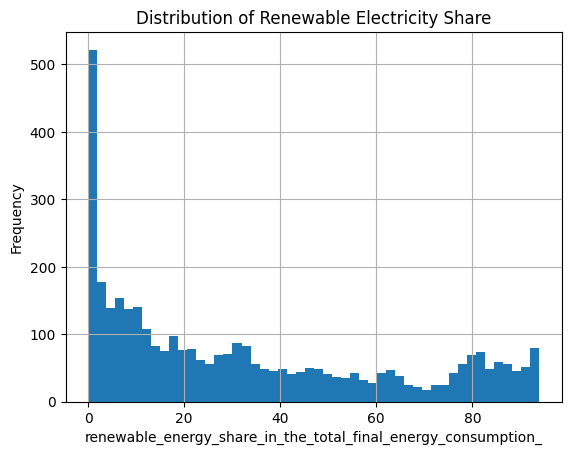

count    3628.000000
mean       32.550730
std        29.762683
min         0.000000
25%         6.602500
50%        23.325000
75%        54.770000
max        93.907300
Name: renewable_energy_share_in_the_total_final_energy_consumption_, dtype: float64


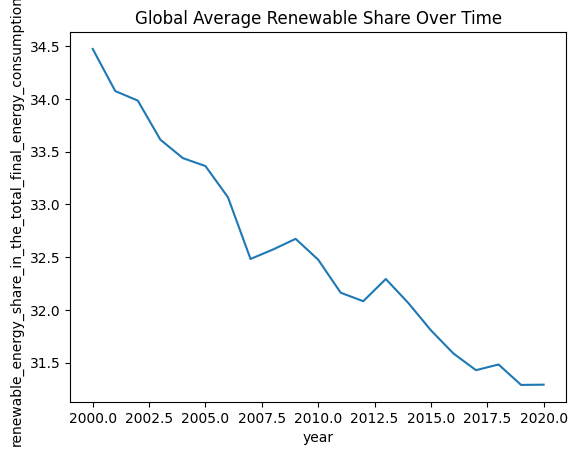

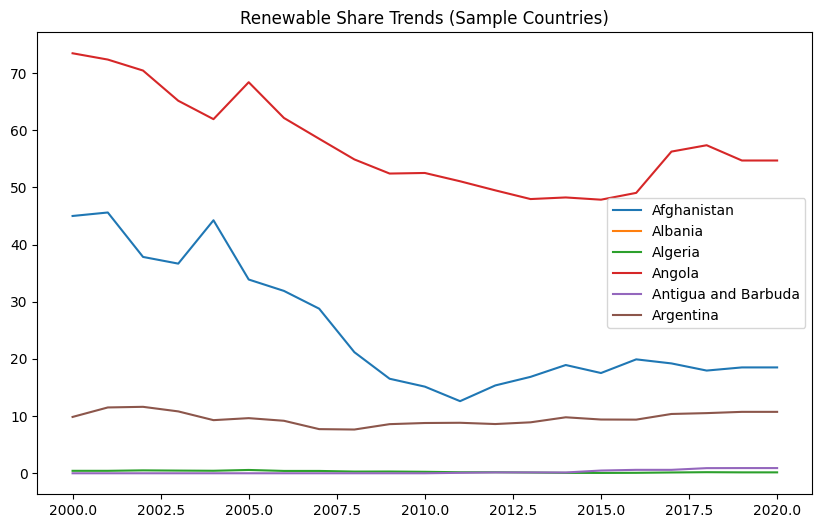

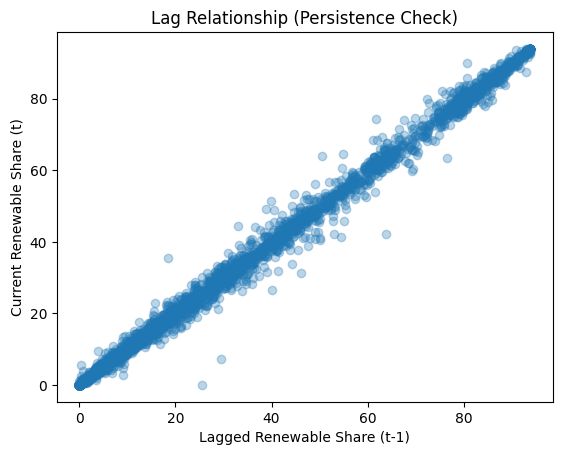

Correlation (lag1 vs current): 0.9977672817099977


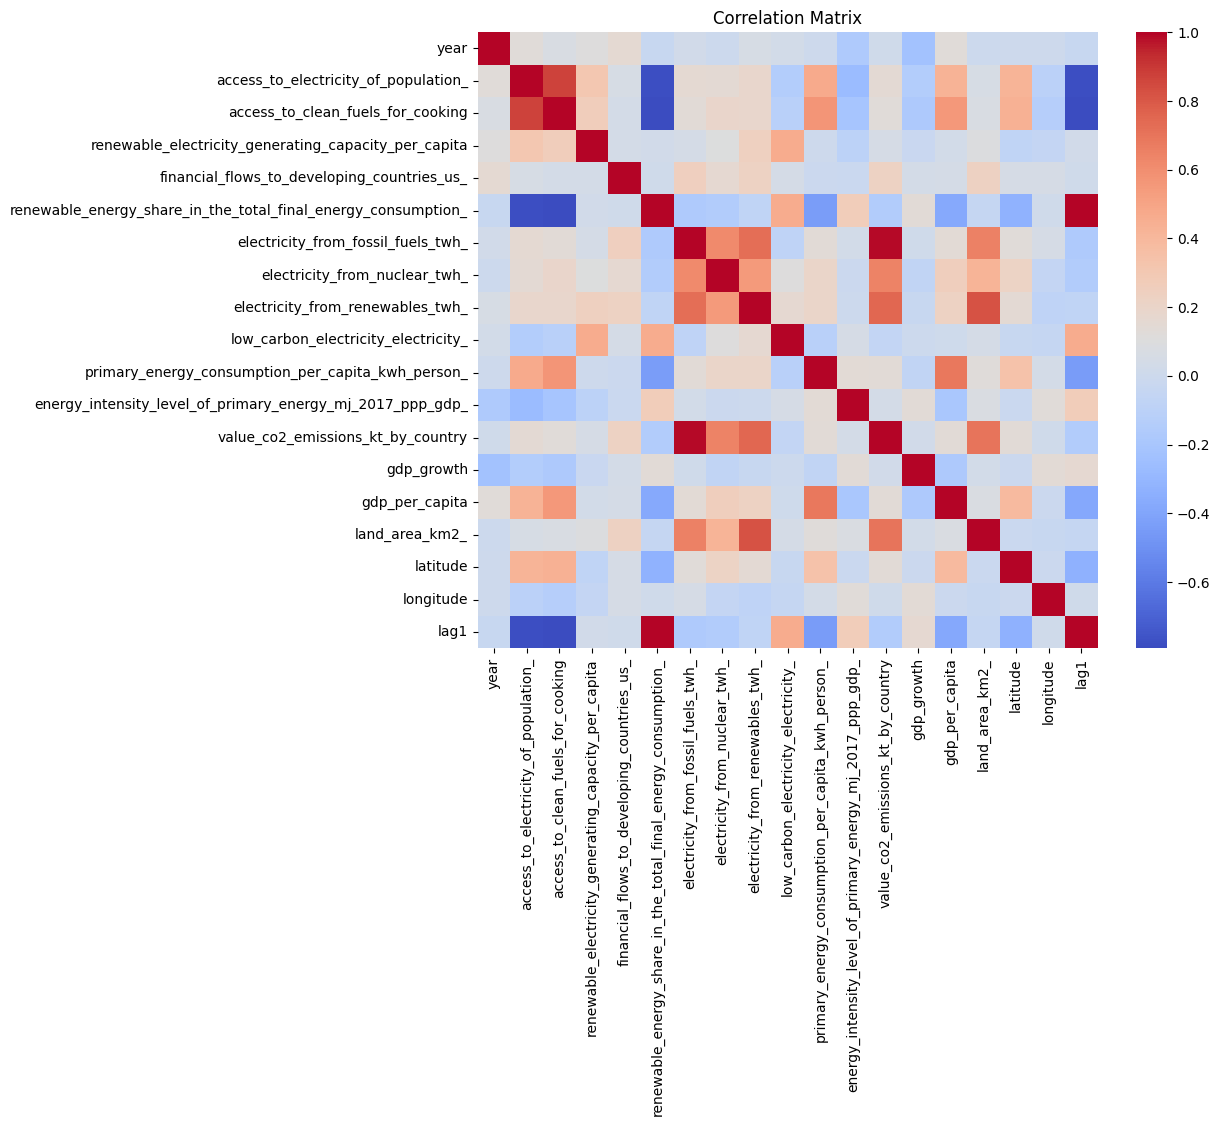


Top correlations with target:
renewable_energy_share_in_the_total_final_energy_consumption_    1.000000
lag1                                                             0.997767
low_carbon_electricity_electricity_                              0.466612
energy_intensity_level_of_primary_energy_mj_2017_ppp_gdp_        0.264946
gdp_growth                                                       0.136111
renewable_electricity_generating_capacity_per_capita             0.022029
financial_flows_to_developing_countries_us_                      0.017349
longitude                                                        0.017291
year                                                            -0.030934
land_area_km2_                                                  -0.045063
Name: renewable_energy_share_in_the_total_final_energy_consumption_, dtype: float64


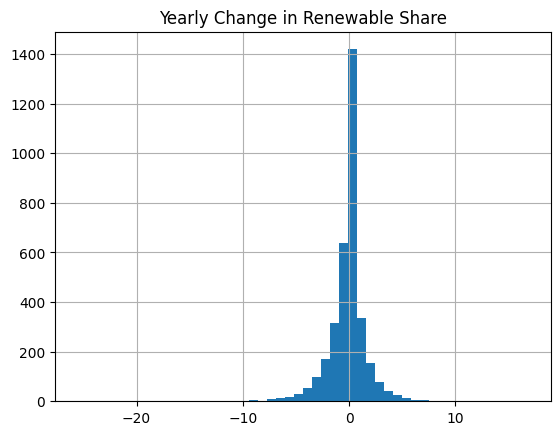

count    3453.000000
mean       -0.158551
std         1.998226
min       -25.570000
25%        -0.710000
50%         0.000000
75%         0.470000
max        16.880000
Name: delta, dtype: float64

Countries with stagnation or decline:
entity
Equatorial Guinea       -1.9635
Bangladesh              -1.7155
Ghana                   -1.4910
Cambodia                -1.4110
Indonesia               -1.3265
Afghanistan             -1.3240
Samoa                   -1.2740
Saint Kitts and Nevis   -1.2530
Tajikistan              -1.1925
Benin                   -1.1910
Name: delta, dtype: float64


/tmp/ipykernel_12068/1173524508.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gdp_trend = df.groupby(["year", "gdp_group"])[target].mean().unstack()


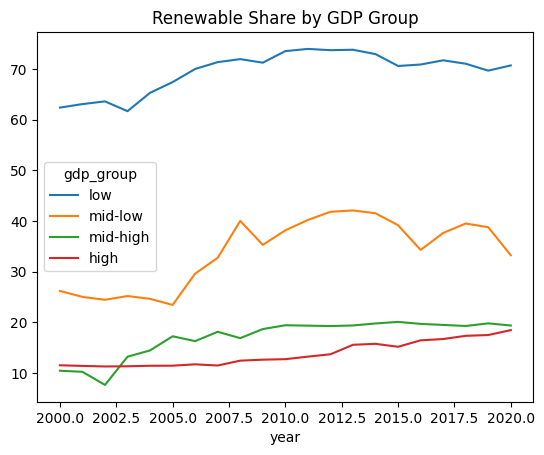


Missing ratio (top columns):
financial_flows_to_developing_countries_us_                      0.324472
renewable_electricity_generating_capacity_per_capita             0.255138
value_co2_emissions_kt_by_country                                0.069334
gdp_per_capita                                                   0.063579
gdp_group                                                        0.063579
gdp_growth                                                       0.063579
delta                                                            0.053713
lag1                                                             0.053713
access_to_clean_fuels_for_cooking                                0.046314
electricity_from_nuclear_twh_                                    0.034530
low_carbon_electricity_electricity_                              0.011510
energy_intensity_level_of_primary_energy_mj_2017_ppp_gdp_        0.006029
electricity_from_fossil_fuels_twh_                               0.005755
electric

In [ ]:
# EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load cleaned data
df = pd.read_csv("cleaned_sustainable_energy.csv")

target = "renewable_energy_share_in_the_total_final_energy_consumption_"

# =========================
# 1. Target Distribution
# =========================
plt.figure()
df[target].hist(bins=50)
plt.title("Distribution of Renewable Electricity Share")
plt.xlabel(target)
plt.ylabel("Frequency")
plt.show()

print(df[target].describe())


# =========================
# 2. Global Trend (supports forecasting)
# =========================
global_trend = df.groupby("year")[target].mean()

plt.figure()
global_trend.plot()
plt.title("Global Average Renewable Share Over Time")
plt.ylabel(target)
plt.show()


# =========================
# 3. Country-level trends (heterogeneity)
# =========================
sample_countries = df["entity"].dropna().unique()[:6]

plt.figure(figsize=(10,6))
for c in sample_countries:
    temp = df[df["entity"] == c]
    plt.plot(temp["year"], temp[target], label=c)

plt.legend()
plt.title("Renewable Share Trends (Sample Countries)")
plt.show()


# =========================
# 4. Lag relationship (AR(1) justification)
# =========================
df["lag1"] = df.groupby("entity")[target].shift(1)

plt.figure()
plt.scatter(df["lag1"], df[target], alpha=0.3)
plt.xlabel("Lagged Renewable Share (t-1)")
plt.ylabel("Current Renewable Share (t)")
plt.title("Lag Relationship (Persistence Check)")
plt.show()

print("Correlation (lag1 vs current):",
      df[[target, "lag1"]].corr().iloc[0,1])


# =========================
# 5. Correlation with predictors (feature question)
# =========================
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# focus on correlation with target
target_corr = corr[target].sort_values(ascending=False)
print("\nTop correlations with target:")
print(target_corr.head(10))


# =========================
# 6. Transition dynamics (risk detection)
# =========================
df["delta"] = df.groupby("entity")[target].diff()

plt.figure()
df["delta"].hist(bins=50)
plt.title("Yearly Change in Renewable Share")
plt.show()

print(df["delta"].describe())


# =========================
# 7. Identify stagnation / decline countries
# =========================
recent_trend = df.groupby("entity")["delta"].mean()

stagnation = recent_trend[recent_trend <= 0]

print("\nCountries with stagnation or decline:")
print(stagnation.sort_values().head(10))


# =========================
# 8. GDP-based grouping (evaluation segmentation)
# =========================
if "gdp_per_capita" in df.columns:
    df["gdp_group"] = pd.qcut(
        df["gdp_per_capita"],
        4,
        labels=["low", "mid-low", "mid-high", "high"]
    )

    gdp_trend = df.groupby(["year", "gdp_group"])[target].mean().unstack()

    gdp_trend.plot()
    plt.title("Renewable Share by GDP Group")
    plt.show()


# =========================
# 9. Missingness check (data quality)
# =========================
missing = df.isnull().mean().sort_values(ascending=False)

print("\nMissing ratio (top columns):")
print(missing.head(15))


### Lag features for RQ3

We build three lag-based features:
- `lag1` (y_{t−1}) — the persistence signal; the IEA's implicit baseline.
- `lag2` (y_{t−2}) — captures whether persistence holds across two years or whether last year was a one-off.
- `delta_lag1` (y_t − y_{t−1}) — captures *direction*, not level. The IEA flags stagnation when a country's year-over-year change stalls or turns negative, so this feature is the most direct numerical link to the transition-risk framing in RQ2.

In [ ]:
# =========================
# STEP 1: Prepare modeling dataset for RQ3
# =========================

import pandas as pd
import numpy as np

# load cleaned data (from your previous step)
df = pd.read_csv("cleaned_sustainable_energy.csv")

target = "renewable_energy_share_in_the_total_final_energy_consumption_"

# ensure sorted panel
df = df.sort_values(["entity", "year"]).reset_index(drop=True)

# -------------------------
# create lag features
# -------------------------
df["lag1"] = df.groupby("entity")[target].shift(1)
df["lag2"] = df.groupby("entity")[target].shift(2)

# change feature (important for trend)
df["delta_lag1"] = df.groupby("entity")[target].diff(1)

# -------------------------
# basic checks
# -------------------------
print("Shape:", df.shape)
print("Year range:", df["year"].min(), "to", df["year"].max())

print("\nMissing values (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))

print("\nPreview with lags:")
print(df[["entity", "year", target, "lag1", "lag2", "delta_lag1"]].head(10))

# -------------------------
# drop rows where lag1 is missing (cannot model without it)
# -------------------------
model_df = df.dropna(subset=["lag1", target]).copy()

print("\nAfter dropping missing lag1:")
print("Shape:", model_df.shape)

# -------------------------
# check one country to confirm lags are correct
# -------------------------
sample_country = model_df["entity"].iloc[0]

print(f"\nSample country check: {sample_country}")
print(
    model_df[model_df["entity"] == sample_country][
        ["year", target, "lag1", "lag2", "delta_lag1"]
    ].head(10)
)

Shape: (3649, 23)
Year range: 2000.0 to 2020.0

Missing values (top 10):
financial_flows_to_developing_countries_us_             1184
renewable_electricity_generating_capacity_per_capita     931
lag2                                                     370
value_co2_emissions_kt_by_country                        253
gdp_per_capita                                           232
gdp_growth                                               232
delta_lag1                                               196
lag1                                                     196
access_to_clean_fuels_for_cooking                        169
electricity_from_nuclear_twh_                            126
dtype: int64

Preview with lags:
        entity    year  \
0  Afghanistan  2000.0   
1  Afghanistan  2001.0   
2  Afghanistan  2002.0   
3  Afghanistan  2003.0   
4  Afghanistan  2004.0   
5  Afghanistan  2005.0   
6  Afghanistan  2006.0   
7  Afghanistan  2007.0   
8  Afghanistan  2008.0   
9  Afghanistan  2009.0  

In [ ]:
# =========================
# STEP 2: First model comparison (lag vs lag + energy)
# =========================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -------------------------
# define features
# -------------------------

lag_features = ["lag1", "lag2", "delta_lag1"]

energy_features = [
    "low_carbon_electricity_electricity_",
    "electricity_from_renewables_twh_",
    "electricity_from_fossil_fuels_twh_",
    "electricity_from_nuclear_twh_",
    "renewable_electricity_generating_capacity_per_capita",
    "energy_intensity_level_of_primary_energy_mj_2017_ppp_gdp_",
    "primary_energy_consumption_per_capita_kwh_person_",
    "value_co2_emissions_kt_by_country"
]

# keep only columns that exist
energy_features = [col for col in energy_features if col in model_df.columns]

print("Energy features used:", energy_features)

# -------------------------
# expanding window function
# -------------------------

def expanding_backtest(data, features, target, start_year=2006):

    years = sorted(data["year"].unique())
    test_years = [y for y in years if y >= start_year]

    preds = []

    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])

    for test_year in test_years:

        train = data[data["year"] < test_year]
        test = data[data["year"] == test_year]

        if len(train) == 0 or len(test) == 0:
            continue

        X_train = train[features]
        y_train = train[target]

        X_test = test[features]
        y_test = test[target]

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        temp = test[["entity", "year"]].copy()
        temp["actual"] = y_test.values
        temp["pred"] = y_pred

        preds.append(temp)

    preds_df = pd.concat(preds, ignore_index=True)

    mae = mean_absolute_error(preds_df["actual"], preds_df["pred"])
    rmse = np.sqrt(mean_squared_error(preds_df["actual"], preds_df["pred"]))

    return mae, rmse

# -------------------------
# run models
# -------------------------

mae_lag, rmse_lag = expanding_backtest(model_df, lag_features, target)
mae_energy, rmse_energy = expanding_backtest(model_df, lag_features + energy_features, target)

print("\n=== RESULTS ===")
print("Lag-only model:")
print("MAE:", mae_lag)
print("RMSE:", rmse_lag)

print("\nLag + Energy features:")
print("MAE:", mae_energy)
print("RMSE:", rmse_energy)

print("\nImprovement (negative = better):")
print("MAE change:", mae_energy - mae_lag)
print("RMSE change:", rmse_energy - rmse_lag)

Energy features used: ['low_carbon_electricity_electricity_', 'electricity_from_renewables_twh_', 'electricity_from_fossil_fuels_twh_', 'electricity_from_nuclear_twh_', 'renewable_electricity_generating_capacity_per_capita', 'energy_intensity_level_of_primary_energy_mj_2017_ppp_gdp_', 'primary_energy_consumption_per_capita_kwh_person_', 'value_co2_emissions_kt_by_country']

=== RESULTS ===
Lag-only model:
MAE: 0.008101140892539035
RMSE: 0.011803890204968087

Lag + Energy features:
MAE: 0.015002112971695486
RMSE: 0.02141287306461471

Improvement (negative = better):
MAE change: 0.0069009720791564505
RMSE change: 0.009608982859646622


In [ ]:
# =========================
# STEP 3: Full comparison + feature importance
# =========================

# -------------------------
# define more feature groups
# -------------------------

macro_features = [
    "gdp_per_capita",
    "gdp_growth",
    "financial_flows_to_developing_countries_us_"
]

development_features = [
    "access_to_electricity_of_population_",
    "access_to_clean_fuels_for_cooking"
]

# keep only existing columns
macro_features = [col for col in macro_features if col in model_df.columns]
development_features = [col for col in development_features if col in model_df.columns]

# -------------------------
# full feature set
# -------------------------

full_features = lag_features + energy_features + macro_features + development_features

# -------------------------
# run models
# -------------------------

mae_full, rmse_full = expanding_backtest(model_df, full_features, target)

print("\n=== FULL MODEL RESULTS ===")
print("MAE:", mae_full)
print("RMSE:", rmse_full)

# -------------------------
# compare all models
# -------------------------

print("\n=== SUMMARY ===")
print("Lag only RMSE:", rmse_lag)
print("Lag + Energy RMSE:", rmse_energy)
print("Full model RMSE:", rmse_full)

# -------------------------
# FEATURE IMPORTANCE (KEY PART)
# Leave-one-group-out
# -------------------------

results = []

groups = {
    "energy": energy_features,
    "macro": macro_features,
    "development": development_features
}

for name, group in groups.items():

    reduced_features = [f for f in full_features if f not in group]

    _, rmse_reduced = expanding_backtest(model_df, reduced_features, target)

    results.append({
        "removed_group": name,
        "rmse_without_group": rmse_reduced,
        "rmse_full": rmse_full,
        "rmse_increase": rmse_reduced - rmse_full
    })

importance_df = pd.DataFrame(results).sort_values("rmse_increase", ascending=False)

print("\n=== FEATURE IMPORTANCE (GROUP LEVEL) ===")
print(importance_df)


=== FULL MODEL RESULTS ===
MAE: 0.03081743936117435
RMSE: 0.04687554514657163

=== SUMMARY ===
Lag only RMSE: 0.011803890204968087
Lag + Energy RMSE: 0.02141287306461471
Full model RMSE: 0.04687554514657163

=== FEATURE IMPORTANCE (GROUP LEVEL) ===
  removed_group  rmse_without_group  rmse_full  rmse_increase
1         macro            0.046619   0.046876      -0.000257
0        energy            0.035303   0.046876      -0.011573
2   development            0.021480   0.046876      -0.025396


=== RQ3 MODEL COMPARISON TABLE ===
          Model       MAE      RMSE
0      Lag only  0.008101  0.011804
1  Lag + Energy  0.015002  0.021413
2    Full model  0.030817  0.046876


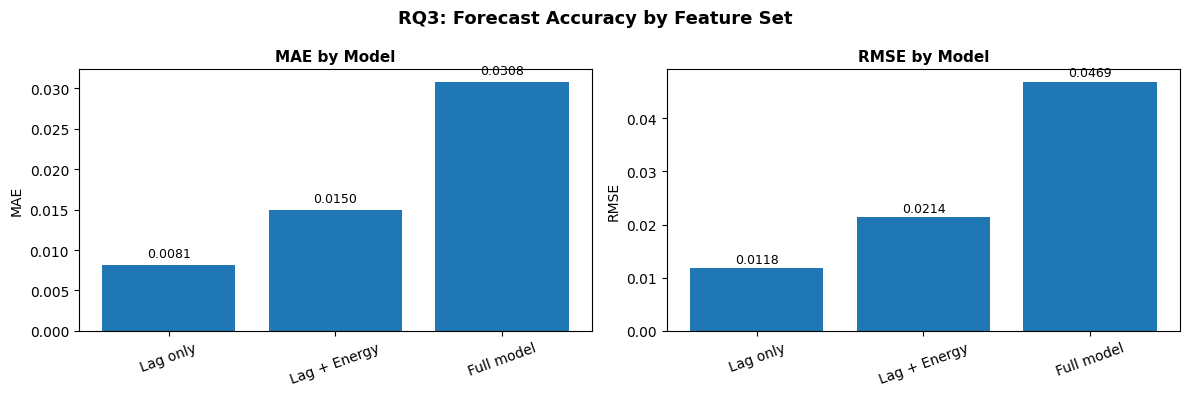


=== GROUP-LEVEL FEATURE IMPORTANCE ===
  removed_group  rmse_without_group  rmse_full  rmse_increase
1         macro            0.046619   0.046876      -0.000257
0        energy            0.035303   0.046876      -0.011573
2   development            0.021480   0.046876      -0.025396


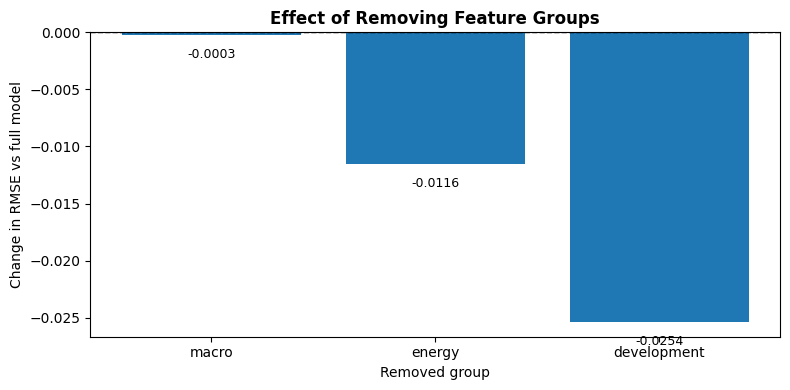


Saved files:
- rq3_model_comparison.csv
- rq3_group_importance.csv


In [ ]:
# =========================
# STEP 4: RQ3 summary tables + core visualizations
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1. Build summary table
# -------------------------

rq3_summary = pd.DataFrame({
    "Model": ["Lag only", "Lag + Energy", "Full model"],
    "MAE": [mae_lag, mae_energy, mae_full],
    "RMSE": [rmse_lag, rmse_energy, rmse_full]
})

print("=== RQ3 MODEL COMPARISON TABLE ===")
print(rq3_summary.round(6))

# save
rq3_summary.to_csv("rq3_model_comparison.csv", index=False)

# -------------------------
# 2. Bar chart: MAE and RMSE by model
# -------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# MAE
axes[0].bar(rq3_summary["Model"], rq3_summary["MAE"])
axes[0].set_title("MAE by Model", fontsize=11, fontweight="bold")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=20)

for i, v in enumerate(rq3_summary["MAE"]):
    axes[0].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9)

# RMSE
axes[1].bar(rq3_summary["Model"], rq3_summary["RMSE"])
axes[1].set_title("RMSE by Model", fontsize=11, fontweight="bold")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=20)

for i, v in enumerate(rq3_summary["RMSE"]):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9)

plt.suptitle("RQ3: Forecast Accuracy by Feature Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# -------------------------
# 3. Leave-one-group-out importance table
# -------------------------

importance_df = importance_df.copy()
importance_df = importance_df.sort_values("rmse_increase", ascending=False)

print("\n=== GROUP-LEVEL FEATURE IMPORTANCE ===")
print(importance_df.round(6))

importance_df.to_csv("rq3_group_importance.csv", index=False)

# -------------------------
# 4. Bar chart: RMSE change when removing each group
# -------------------------

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(importance_df["removed_group"], importance_df["rmse_increase"])
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Effect of Removing Feature Groups", fontsize=12, fontweight="bold")
ax.set_xlabel("Removed group")
ax.set_ylabel("Change in RMSE vs full model")

for i, v in enumerate(importance_df["rmse_increase"]):
    ax.text(i, v + (0.001 if v >= 0 else -0.002), f"{v:.4f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\nSaved files:")
print("- rq3_model_comparison.csv")
print("- rq3_group_importance.csv")

**Stakeholder takeaway.** The lag-only model outperforms every richer feature set we tested. For the IEA's 1–3 year monitoring horizon, this confirms that energy-system inertia — encoded in lag1 — is the dominant predictive signal at the country level. Adding more features pulls in noise without improving accuracy, which aligns with the IEA's stated preference for stable, interpretable short-term forecasts. The practical implication: countries whose realized share deviates meaningfully from a lag1 projection are precisely the ones the IEA should prioritize for closer monitoring, since they're the ones breaking from the structural baseline.

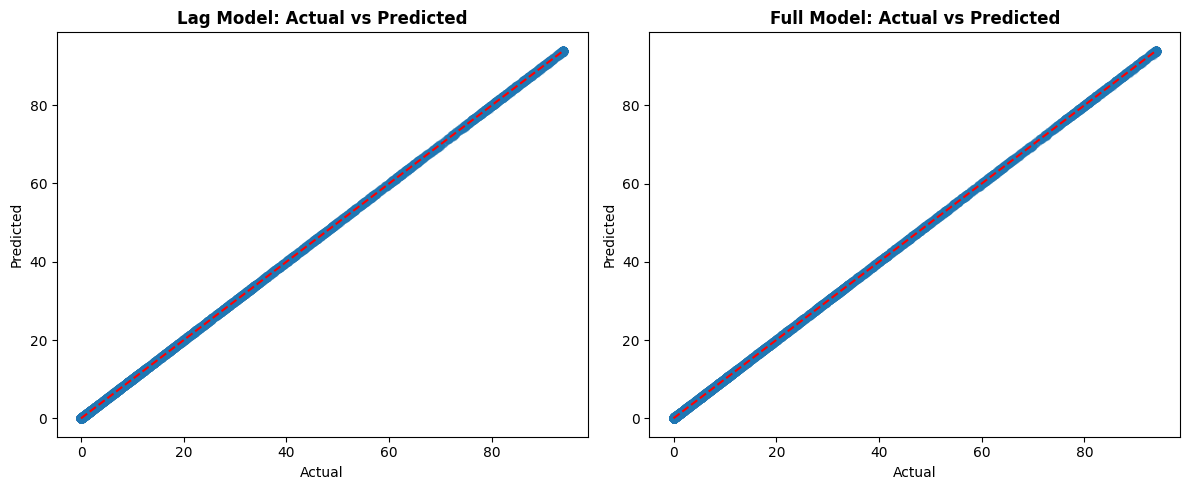

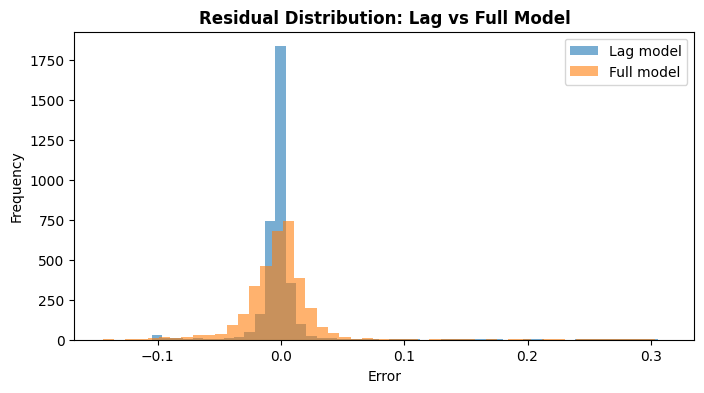


=== TOP FEATURES (FULL MODEL) ===
                                              feature  importance
0                                                lag1   29.699388
2                                          delta_lag1    1.995873
1                                                lag2    0.127106
14               access_to_electricity_of_population_   -0.020181
15                  access_to_clean_fuels_for_cooking   -0.015933
3                 low_carbon_electricity_electricity_    0.013287
10                  value_co2_emissions_kt_by_country   -0.005547
8   energy_intensity_level_of_primary_energy_mj_20...    0.004775
11                                     gdp_per_capita    0.004491
7   renewable_electricity_generating_capacity_per_...    0.004253
4                    electricity_from_renewables_twh_    0.003828
5                  electricity_from_fossil_fuels_twh_    0.003184
6                       electricity_from_nuclear_twh_   -0.003172
9   primary_energy_consumption_per_capita

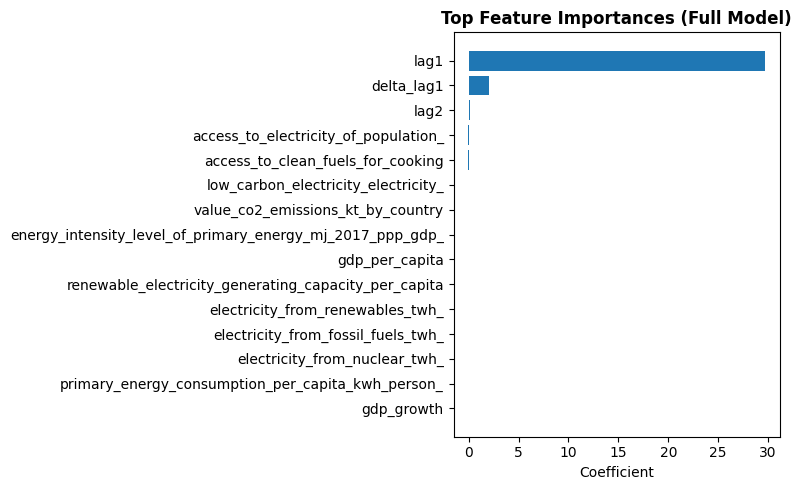

In [ ]:
# =========================
# STEP 5: Advanced visuals (this makes it Q1/Q2 level)
# =========================

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# -------------------------
# 1. Fit models on full data (for visualization only)
# -------------------------

pipeline_lag = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

pipeline_full = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

X_lag = model_df[lag_features]
X_full = model_df[full_features]
y = model_df[target]

pipeline_lag.fit(X_lag, y)
pipeline_full.fit(X_full, y)

pred_lag = pipeline_lag.predict(X_lag)
pred_full = pipeline_full.predict(X_full)

# -------------------------
# 2. Actual vs Predicted
# -------------------------

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Lag model
axes[0].scatter(y, pred_lag, alpha=0.3)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[0].set_title("Lag Model: Actual vs Predicted", fontweight="bold")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

# Full model
axes[1].scatter(y, pred_full, alpha=0.3)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[1].set_title("Full Model: Actual vs Predicted", fontweight="bold")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

# -------------------------
# 3. Residual distribution
# -------------------------

res_lag = y - pred_lag
res_full = y - pred_full

plt.figure(figsize=(8, 4))
plt.hist(res_lag, bins=50, alpha=0.6, label="Lag model")
plt.hist(res_full, bins=50, alpha=0.6, label="Full model")
plt.legend()
plt.title("Residual Distribution: Lag vs Full Model", fontweight="bold")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

# -------------------------
# 4. Feature importance (coefficients)
# -------------------------

coef = pipeline_full.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": full_features,
    "importance": coef
}).sort_values("importance", key=abs, ascending=False).head(15)

print("\n=== TOP FEATURES (FULL MODEL) ===")
print(coef_df)

plt.figure(figsize=(8, 5))
plt.barh(coef_df["feature"], coef_df["importance"])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances (Full Model)", fontweight="bold")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

# save
coef_df.to_csv("rq3_feature_importance.csv", index=False)